# Used Car Price Analysis & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('used_cars.csv')

In [3]:
df_original = df.copy()

In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
print(f"Data types of each column :\n {df.dtypes} ")
print(f"\nNull values:\n {df.isnull().sum()}")
print(f"\nDuplicated Rows : {df.duplicated().sum()}")

Data types of each column :
 brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object 

Null values:
 brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Duplicated Rows : 0


In [6]:
df[['milage','price']].head()

,milage,price
0,"51,000 mi.","$10,300"
1,"34,742 mi.","$38,005"
2,"22,372 mi.","$54,598"
3,"88,900 mi.","$15,500"
4,"9,835 mi.","$34,999"


## Clean Price and Milage

In [7]:
df['price'] = df['price'].str.replace('$','',regex = False).str.replace(',','',regex = False).astype(float)
df['milage'] = df['milage'].str.replace('mi.','',regex = False).str.replace(',','',regex = False).astype(float)

In [8]:
print(df[['milage','price']].dtypes)
(df[['milage','price']].head())

milage    float64
price     float64
dtype: object


,milage,price
0,51000.0,10300.0
1,34742.0,38005.0
2,22372.0,54598.0
3,88900.0,15500.0
4,9835.0,34999.0


In [9]:
df['brand'].str.strip().unique()

array(['Ford', 'Hyundai', 'Lexus', 'INFINITI', 'Audi', 'Acura', 'BMW',
       'Tesla', 'Land', 'Aston', 'Toyota', 'Lincoln', 'Jaguar',
       'Mercedes-Benz', 'Dodge', 'Nissan', 'Genesis', 'Chevrolet', 'Kia',
       'Jeep', 'Bentley', 'Honda', 'Lucid', 'MINI', 'Porsche', 'Hummer',
       'Chrysler', 'Volvo', 'Cadillac', 'Lamborghini', 'Maserati',
       'Volkswagen', 'Subaru', 'Rivian', 'GMC', 'RAM', 'Alfa', 'Ferrari',
       'Scion', 'Mitsubishi', 'Mazda', 'Saturn', 'Bugatti', 'Polestar',
       'Rolls-Royce', 'McLaren', 'Buick', 'Lotus', 'Pontiac', 'FIAT',
       'Karma', 'Saab', 'Mercury', 'Plymouth', 'smart', 'Maybach',
       'Suzuki'], dtype=object)

In [10]:
df['model'].str.split().str[0].value_counts().head(30)

model
Rover         130
Model          87
911            80
Wrangler       73
F-150          64
Corvette       61
Mustang        61
AMG            60
1500           56
F-250          47
Silverado      46
E-Class        46
Escalade       45
Camaro         45
X5             38
Suburban       38
M3             37
Expedition     34
RX             33
Grand          31
Sierra         31
Cayenne        30
Yukon          30
Explorer       29
C-Class        28
Bronco         27
GX             26
Highlander     26
4Runner        25
Tundra         25
Name: count, dtype: int64

In [11]:
fixes = {
    'Land' : ('Land Rover', 'Rover '),
    'Aston' : ('Aston Martin', 'Martin '),
    'Alfa': ('Alfa Romeo', 'Romeo ')
}

for short, (full, prefix) in fixes.items():
    mask = df['brand'] == short
    df.loc[mask,'model'] = df.loc[mask,'model'].str.replace(prefix,"",n = 1,regex = False)
    df.loc[mask,'brand'] = full

In [12]:
counts = df['model'].str.split().str[0].value_counts()
print(counts.reindex(['Rover','Martin','Romeo']))

model
Rover    NaN
Martin   NaN
Romeo    NaN
Name: count, dtype: float64


## Handling Missing values

In [13]:
df = df.replace("-",np.nan)
print(f"\n {df[['fuel_type','accident','clean_title']].isnull().sum()}")
print(f"\n{df[['fuel_type','accident','clean_title']].isna().mean() * 100}")
print(f"\n{df[['fuel_type','accident','clean_title']].dtypes}")
print(f"\n{df['clean_title'].value_counts(dropna = False)}")
print(f"\n{df[df['fuel_type'].isna()]['brand'].value_counts().head(10)}")
print(f"\n{df['accident'].value_counts(dropna = False)}")


 fuel_type      170
accident       113
clean_title    596
dtype: int64

fuel_type       4.240459
accident        2.818658
clean_title    14.866550
dtype: float64

fuel_type      object
accident       object
clean_title    object
dtype: object

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

brand
Tesla        87
Rivian       17
Ford         12
Porsche       9
Audi          6
Nissan        5
BMW           5
Chevrolet     5
Kia           4
Lucid         3
Name: count, dtype: int64

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64


In [14]:
cols = ['brand','model','fuel_type','accident','clean_title']
df.loc[df[['fuel_type','accident','clean_title']].isna().any(axis = 1),cols].head()

,brand,model,fuel_type,accident,clean_title
2,Lexus,RX 350 RX 350,Gasoline,None reported,NaN
4,Audi,Q3 45 S line Premium Plus,Gasoline,None reported,NaN
5,Acura,ILX 2.4L,Gasoline,None reported,NaN
9,Tesla,Model X Long Range Plus,NaN,None reported,Yes
10,Land Rover,Range Rover Sport 3.0 Supercharged HST,Gasoline,None reported,NaN


In [15]:
df.loc[(df['brand'] == 'Tesla') & df['fuel_type'].isna(), 'fuel_type'] = 'Electric'

In [16]:
df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df['accident'] = df['accident'].fillna('Unknown')
df['clean_title'] = df['clean_title'].fillna('No')

In [17]:
print(f"\n {df[['fuel_type','accident','clean_title']].isnull().sum()}")


 fuel_type      0
accident       0
clean_title    0
dtype: int64


In [18]:
#Engineering car age and milage per year
#Car age
df['car_age'] = 2025 - df['model_year']
df['car_age'] = df['car_age'].replace(0,1)

#milage per year
df['milage_per_year'] = (df['milage']/ df['car_age']).round(1)

In [19]:
df[['car_age','milage_per_year']].head()

,car_age,milage_per_year
0,12,4250.0
1,4,8685.5
2,3,7457.3
3,10,8890.0
4,4,2458.8


In [20]:
#Engineering brand_tier
luxury_brand = ['Bugatti','Rolls-Royce','Lamborghini','Ferrari',
                'McLaren','Bentley','Lucid','Aston Martin','Mercedes-Benz',
                'BMW','Porsche','Audi','Land Rover','Lexus','Jaguar','Genesis']
def brand_tier(b):
    if b in luxury_brand:
        return 'Luxury'
    else:
        return 'Economy'
df['brand_tier'] = df['brand'].apply(brand_tier)

In [21]:
df['brand_tier'].value_counts()

brand_tier
Economy    2457
Luxury     1552
Name: count, dtype: int64

In [22]:
#Average price by brand_tier
average_price_by_brand_tier = df.groupby('brand_tier')['price'].mean().sort_values(ascending = False).round(1)
average_price_by_brand_tier.reset_index()

,brand_tier,price
0,Luxury,62350.9
1,Economy,33311.0


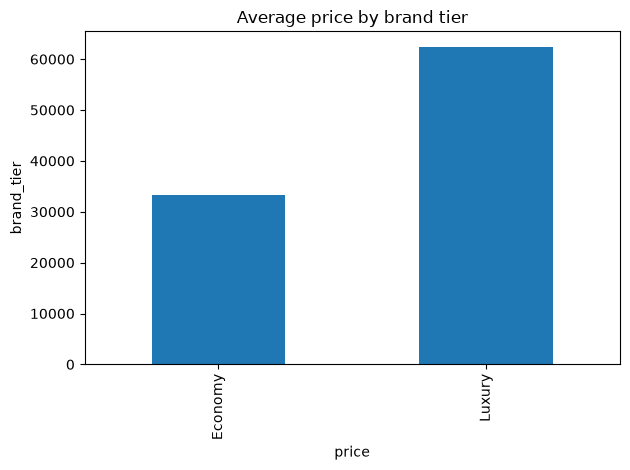

In [23]:
average_price_by_brand_tier.sort_values().plot(kind = 'bar')
plt.title('Average price by brand tier')
plt.xlabel('price')
plt.ylabel('brand_tier')
plt.tight_layout()
plt.savefig('Average_price_by_brand_tier')
plt.show()

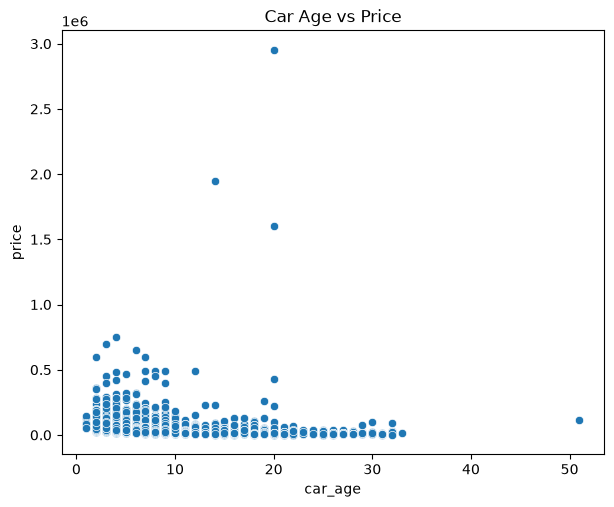

In [24]:
#Car Age vs Price
plt.figure(figsize = (7,5.5))
plt.title('Car Age vs Price')
sns.scatterplot(x = 'car_age',y = 'price',data = df)
plt.savefig('Car_Age VS Price')
plt.show()

In [25]:
#Average Milage per year by brand tier
df.groupby('brand_tier')['milage_per_year'].mean().sort_values(ascending = False).reset_index().round(2)

,brand_tier,milage_per_year
0,Economy,7502.52
1,Luxury,5784.24


In [26]:
df[['milage_per_year','price']].corr()

,milage_per_year,price
milage_per_year,1.00000,-0.24294
price,-0.24294,1.00000


# Business Recomendations

### Which engineered feature (car_age, mileage_per_year, or brand_tier) looks like it predicts price the most reliably?
Among the engineered features, brand_tier appears to be most strongly associated with price, as the average price differs substantially between the brand tiers.



### Is there a milage_per_year range where price drops off sharply, a threshold worth pricing around?


In [27]:
df.groupby(pd.cut(df["milage_per_year"], bins=10))["price"].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19384\1451543107.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["milage_per_year"], bins=10))["price"].mean()


milage_per_year
(-11.0, 4463.3]       75642.501608
(4463.3, 8893.3]      32953.310138
(8893.3, 13323.3]     26728.647420
(13323.3, 17753.3]    25828.294931
(17753.3, 22183.3]    34794.200000
(22183.3, 26613.3]    28236.000000
(26613.3, 31043.3]    49666.666667
(31043.3, 35473.3]    12000.000000
(35473.3, 39903.3]    32662.000000
(39903.3, 44333.3]    24500.000000
Name: price, dtype: float64

The strongest price drop occurs between the 0–4,463 and 4,463–8,893 miles/year ranges, where average price falls from about $75,643 to $32,953. This suggests that around 4,500 miles/year may be a useful pricing threshold. However, the relationship is not consistently decreasing at higher mileage levels.

### Should inventory buying lean more toward luxury or economy tiers based on what you're seeing?
Based on the price patterns observed, inventory buying could lean toward the economy tier because these vehicles generally fall into a more affordable price range. However, this analysis does not directly measure sales or demand, so the conclusion is based on price patterns rather than actual demand.

# Bonus Mystery
Find a listing (or small group of listings) where mileage_per_year looks unrealistic, either far too high or
suspiciously low. Trace it back: is it a genuine outlier, or is it the result of a cleaning mistake earlier in the
pipeline? This is the whole point of chaining cleaning and feature engineering together, a bad cleaned value
quietly produces a bad engineered feature.

In [28]:
df.sort_values('milage_per_year').head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,milage_per_year,brand_tier
3018,GMC,Sierra 1500 AT4,2022,100.0,Diesel,277.0HP 3.0L Straight 6 Cylinder Engine Diesel...,10-Speed A/T,White,Black,None reported,Yes,62499.0,3,33.3,Economy
1848,Mercedes-Benz,Sprinter 3500 High Roof,2022,105.0,Diesel,161.0HP 2.0L 4 Cylinder Engine Diesel Fuel,7-Speed A/T,Black,Orange,None reported,Yes,200000.0,3,35.0,Luxury
487,Rolls-Royce,Cullinan,2022,115.0,Gasoline,6.7L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,–,Grace White,None reported,Yes,449995.0,3,38.3,Luxury
3860,Chevrolet,Tahoe LTZ,2015,500.0,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,37000.0,10,50.0,Economy
331,Hyundai,Veloster Base,2013,800.0,Gasoline,132.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Gray,None reported,Yes,9800.0,12,66.7,Economy
3600,Porsche,911 Turbo S,2023,154.0,Gasoline,3.8L H6 24V GDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,Python Green,Black,None reported,No,274900.0,2,77.0,Luxury
2407,Rivian,R1S Adventure Package,2023,159.0,Unknown,533.0HP Electric Motor Electric Fuel System,A/T,White,Black,None reported,Yes,95500.0,2,79.5,Economy
1148,Porsche,911 R,2016,719.0,Gasoline,4.0L H6 24V GDI DOHC,6-Speed Manual,White,Black / Brown,None reported,Yes,489000.0,9,79.9,Luxury
3764,Audi,Q4 e-tron 50 Premium Plus,2022,250.0,Unknown,295.0HP Electric Motor Electric Fuel System,1-Speed A/T,Gray,Black,None reported,Yes,52000.0,3,83.3,Luxury
293,BMW,i8 Base,2015,846.0,Plug-In Hybrid,357.0HP 1.5L 3 Cylinder Engine Plug-In Electri...,A/T,White,White,None reported,Yes,86999.0,10,84.6,Luxury


In [29]:
df.sort_values('milage_per_year',ascending = False).head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,milage_per_year,brand_tier
3348,Mercedes-Benz,Sprinter 2500,2016,399000.0,Diesel,188.0HP 3.0L V6 Cylinder Engine Diesel Fuel,5-Speed A/T,Silver,–,At least 1 accident or damage reported,Yes,24500.0,9,44333.3,Luxury
116,RAM,ProMaster 3500 High Roof,2021,147834.0,Gasoline,3.6L V6 24V MPFI DOHC,6-Speed Automatic,Bright White Clearcoat,Black,None reported,Yes,32662.0,4,36958.5,Economy
2764,Honda,Accord Sport,2013,405000.0,Gasoline,185.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,CVT Transmission,Black,Black,None reported,Yes,6000.0,12,33750.0,Economy
2232,Ford,Transit-350 Base,2018,235000.0,Gasoline,275.0HP 3.7L V6 Cylinder Engine Gasoline Fuel,A/T,White,Gray,Unknown,No,18000.0,7,33571.4,Economy
2926,Ford,F-250 XLT,2017,244000.0,Diesel,440.0HP 6.7L 8 Cylinder Engine Diesel Fuel,6-Speed A/T,Red,Beige,None reported,Yes,35500.0,8,30500.0,Economy


In [30]:
df.loc[df['milage_per_year'] > 35000]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,milage_per_year,brand_tier
116,RAM,ProMaster 3500 High Roof,2021,147834.0,Gasoline,3.6L V6 24V MPFI DOHC,6-Speed Automatic,Bright White Clearcoat,Black,None reported,Yes,32662.0,4,36958.5,Economy
3348,Mercedes-Benz,Sprinter 2500,2016,399000.0,Diesel,188.0HP 3.0L V6 Cylinder Engine Diesel Fuel,5-Speed A/T,Silver,–,At least 1 accident or damage reported,Yes,24500.0,9,44333.3,Luxury


In [31]:
df_original.loc[3348, "milage"]

'399,000 mi.'

In [32]:
df.loc[3348,'milage']

np.float64(399000.0)

The Mercedes-Benz Sprinter 2500 at index 3348 is a high-end outlier, with 399,000 miles over 9 years, resulting in 44,333.3 miles/year. I traced the mileage back to the original data, where it was recorded as "399,000 mi.". The cleaning step correctly converted this value to 399000.0, so the unusual milage_per_year was not caused by a cleaning mistake. Since the engineered value is also mathematically correct, this appears to be a genuine extreme outlier.